# Residual-Independence Validation via Mutual Information

This notebook produces **Table 8** (Appendix G.1): an empirical check of CRDA's
core assumption that the residual noise $Z$ is independent of the perturbed
features. For each dataset it fits an **XGBoost** base model, computes the
residuals $Z = y - \hat{g}(x)$, then uses **mutual information**
(`sklearn.feature_selection.mutual_info_regression`, a KSG-style estimator) to
measure the dependence between $Z$ and the features CRDA **selects** versus those
it **rejects**. Higher MI for the rejected features confirms the filter is removing
the features that would violate the assumption. Results are averaged over 15 seeds.

---

In [1]:
import sys
import os
sys.path.append(os.path.dirname(os.getcwd()))

from src.utils.config import Config
from src.utils.logger import Logger
from src.experiment import Experiment
from src.dataset import AbstractDataset
from src.baseline import BaselineRegressor
from src.filter import Filter

import torch
import random
import pandas as pd
import numpy as np
from time import perf_counter

from sklearn.feature_selection import mutual_info_regression

DF = pd.DataFrame(columns=['dataset_name', 'mi_selected', 'mi_selected_se', 'mi_rejected', 'mi_rejected_se'])



/Users/hosseinmohebbi/Desktop/code/CRDA/.venv/lib/python3.11/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [2]:
def set_seed(seed):
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    torch.backends.cudnn.deterministic = True
    torch.backends.cudnn.benchmark = False
    if torch.cuda.is_available():
        torch.cuda.manual_seed(seed)
        torch.cuda.manual_seed_all(seed)
        
def get_dataset_name(config):
    return os.path.basename(config.dataset_path).split('.')[0]

def get_ready_dataset(config):
    dataset_name = get_dataset_name(config)
    dataset = AbstractDataset(dataset_name, config.dataset_path, seed=config.random_seed)
    dataset.preprocess()
    dataset.split(test_size=config.test_size, seed=config.random_seed)
    return dataset

def get_residuals(dataset: AbstractDataset, baseline: BaselineRegressor):
    _, train_residuals, _ = dataset.add_residuals(baseline)
    return train_residuals

def add_row(dataset_name, mi_selected, mi_selected_se, mi_rejected, mi_rejected_se):
    row_data = {
        'dataset_name': dataset_name,
        'mi_selected': mi_selected,
        'mi_selected_se': mi_selected_se,
        'mi_rejected': mi_rejected,
        'mi_rejected_se': mi_rejected_se
    }
    global DF
    DF = pd.concat([DF, pd.DataFrame([row_data])], ignore_index=True)
    

In [3]:
def calculate_mis(config, dataset, Z, best_features_to_perturb):
    features_to_perturb_indices = best_features_to_perturb[:config.max_n_features_to_perturb]

    all_indices = set(range(dataset.X_train.shape[1]))
    rejected = list(all_indices - set(features_to_perturb_indices))

    X_P = dataset.X_train[:, features_to_perturb_indices]
    X_R = dataset.X_train[:, rejected]

    # assert both are not empty
    assert X_P.shape[1] > 0 and X_R.shape[1] > 0, "X_P and X_R cannot be empty"

    mi_selected = mutual_info_regression(X_P, Z, discrete_features=False, random_state=config.random_seed)
    mi_rejected = mutual_info_regression(X_R, Z, discrete_features=False, random_state=config.random_seed)
    return mi_selected, mi_rejected

def get_mis(config):
    logger = Logger(log_to_file=False, log_to_console=False)
    experiment = Experiment(config, logger)
        
    dataset = get_ready_dataset(config)
    baseline = BaselineRegressor(config.baseline)

    experiment._train_baseline(dataset, baseline, seed=config.random_seed)
    Z = get_residuals(dataset, baseline)

    filter = Filter(dataset, config, logger)
    best_features_to_perturb = filter.run_checks()

    num_features = dataset.X_train.shape[1]
    max_n_features_to_perturb_range = range(1, num_features)  # Exclude all features (need at least 1 rejected)

    # Iterate over all possible values to find the optimal one
    best_n_features = None
    best_gap = -np.inf
    best_mi_selected = None
    best_mi_rejected = None
    
    for n_features in max_n_features_to_perturb_range:
        config.max_n_features_to_perturb = n_features
        mi_selected, mi_rejected = calculate_mis(config, dataset, Z, best_features_to_perturb)
        
        # Calculate mean MI for comparison
        mi_selected_mean = np.mean(mi_selected)
        mi_rejected_mean = np.mean(mi_rejected)
        
        # Calculate gap (we want mi_rejected > mi_selected)
        gap = mi_rejected_mean - mi_selected_mean
        
        # Update best if this configuration has better gap and satisfies constraint
        if gap > best_gap and mi_selected_mean < mi_rejected_mean:
            best_gap = gap
            best_n_features = n_features
            best_mi_selected = mi_selected
            best_mi_rejected = mi_rejected
    
    # If no valid configuration found (all have mi_selected >= mi_rejected), 
    # just use the one with smallest mi_selected
    if best_n_features is None:
        print("Warning: No configuration found with mi_selected < mi_rejected. Using smallest mi_selected.")
        best_mi_selected_mean = np.inf
        for n_features in max_n_features_to_perturb_range:
            config.max_n_features_to_perturb = n_features
            mi_selected, mi_rejected = calculate_mis(config, dataset, Z, best_features_to_perturb)
            mi_selected_mean = np.mean(mi_selected)
            if mi_selected_mean < best_mi_selected_mean:
                best_mi_selected_mean = mi_selected_mean
                best_n_features = n_features
                best_mi_selected = mi_selected
                best_mi_rejected = mi_rejected
    
    print(f"Optimal max_n_features_to_perturb: {best_n_features} (gap: {best_gap:.5f})")
    
    return best_mi_selected, best_mi_rejected

def plot(mi_selected_mean, mi_selected_stderr, mi_rejected_mean, mi_rejected_stderr):
    import matplotlib.pyplot as plt
    import seaborn as sns
    import pandas as pd

    # Use avg & stderr to produce an errorbar bar plot
    groups = ['Selected', 'Rejected']
    means = [mi_selected_mean, mi_rejected_mean]
    stderrs = [mi_selected_stderr, mi_rejected_stderr]

    plt.figure(figsize=(6, 4))
    bar = plt.bar(groups, means, yerr=stderrs, capsize=8, color=sns.color_palette("Set2", n_colors=2))
    plt.title("Divergence (Mutual Information) with Residuals")
    plt.ylabel("Mutual Information (nats)")
    plt.xlabel("Feature Set")

    # Optionally, annotate with means ± stderrs
    for i, (mean, stderr) in enumerate(zip(means, stderrs)):
        plt.text(i, mean + stderr + 0.01, f"{mean:.3f}±{stderr:.3f}", ha='center', va='bottom', fontsize=10)
    
    plt.tight_layout()
    plt.show()

def run(config):
    start_time = perf_counter()
    set_seed(config.random_seed)
    seeds = [random.randint(0, 1000000) for _ in range(config.num_seeds)]

    mi_selected_list = []
    mi_rejected_list = []
    for seed in seeds:
        config.random_seed = seed
        try:
            mi_selected, mi_rejected = get_mis(config)
            mi_selected_list.append(mi_selected)
            mi_rejected_list.append(mi_rejected)
        except Exception as e:
            continue
    
    # Flatten the lists to handle varying feature counts across seeds
    mi_selected = np.concatenate(mi_selected_list)
    mi_rejected = np.concatenate(mi_rejected_list)

    # Calculate averages and standard errors
    mi_selected_mean = np.mean(mi_selected)
    mi_selected_stderr = np.std(mi_selected, ddof=1) / np.sqrt(mi_selected.size)
    mi_rejected_mean = np.mean(mi_rejected)
    mi_rejected_stderr = np.std(mi_rejected, ddof=1) / np.sqrt(mi_rejected.size)

    plot(mi_selected_mean, mi_selected_stderr, mi_rejected_mean, mi_rejected_stderr)

    print("--- Mutual Information (KL-Divergence equivalent) ---")
    print(f"Average MI for SELECTED features: {mi_selected_mean:.5f} ± {mi_selected_stderr:.5f}")
    print(f"Average MI for REJECTED features: {mi_rejected_mean:.5f} ± {mi_rejected_stderr:.5f}")

    add_row(get_dataset_name(config), mi_selected_mean, mi_selected_stderr, mi_rejected_mean, mi_rejected_stderr)

    end_time = perf_counter()
    print(f"Time taken: {end_time - start_time:.2f} seconds")


Optimal max_n_features_to_perturb: 1 (gap: 0.00542)
Optimal max_n_features_to_perturb: 2 (gap: 0.00531)
Optimal max_n_features_to_perturb: 2 (gap: 0.01213)
Optimal max_n_features_to_perturb: 4 (gap: 0.01092)
Optimal max_n_features_to_perturb: 1 (gap: 0.01001)
Optimal max_n_features_to_perturb: 1 (gap: 0.00518)
Optimal max_n_features_to_perturb: 1 (gap: 0.00077)
Optimal max_n_features_to_perturb: 2 (gap: 0.00366)
Optimal max_n_features_to_perturb: 4 (gap: 0.00953)
Optimal max_n_features_to_perturb: 3 (gap: 0.01821)
Optimal max_n_features_to_perturb: 2 (gap: 0.00558)
Optimal max_n_features_to_perturb: 2 (gap: -inf)
Optimal max_n_features_to_perturb: 5 (gap: 0.04272)
Optimal max_n_features_to_perturb: 3 (gap: 0.01428)
Optimal max_n_features_to_perturb: 4 (gap: 0.02499)


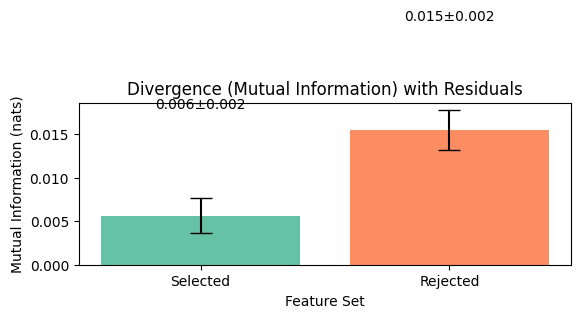

--- Mutual Information (KL-Divergence equivalent) ---
Average MI for SELECTED features: 0.00562 ± 0.00201
Average MI for REJECTED features: 0.01548 ± 0.00227
Time taken: 7.38 seconds


/var/folders/gv/s013xfhx5fx1yvp2tfcstt140000gn/T/ipykernel_19416/3029133818.py:34: FutureWarning: The behavior of DataFrame concatenation with empty or all-NA entries is deprecated. In a future version, this will no longer exclude empty or all-NA columns when determining the result dtypes. To retain the old behavior, exclude the relevant entries before the concat operation.
  DF = pd.concat([DF, pd.DataFrame([row_data])], ignore_index=True)


In [4]:
run(Config(
    baseline="xgboost",
    dataset_path="../data/HousePrice.csv",
    results_dir="../experiments_divergence/HousePrice",
    ignore_filter=True,
))

Optimal max_n_features_to_perturb: 4 (gap: 0.02050)
Optimal max_n_features_to_perturb: 7 (gap: 0.02359)
Optimal max_n_features_to_perturb: 2 (gap: 0.02143)
Optimal max_n_features_to_perturb: 6 (gap: 0.02145)
Optimal max_n_features_to_perturb: 4 (gap: 0.01659)
Optimal max_n_features_to_perturb: 7 (gap: -inf)
Optimal max_n_features_to_perturb: 2 (gap: 0.00654)
Optimal max_n_features_to_perturb: 1 (gap: 0.01133)
Optimal max_n_features_to_perturb: 5 (gap: -inf)
Optimal max_n_features_to_perturb: 6 (gap: 0.00304)
Optimal max_n_features_to_perturb: 7 (gap: 0.06414)
Optimal max_n_features_to_perturb: 6 (gap: 0.01862)
Optimal max_n_features_to_perturb: 7 (gap: -inf)
Optimal max_n_features_to_perturb: 3 (gap: 0.02049)
Optimal max_n_features_to_perturb: 7 (gap: 0.02607)


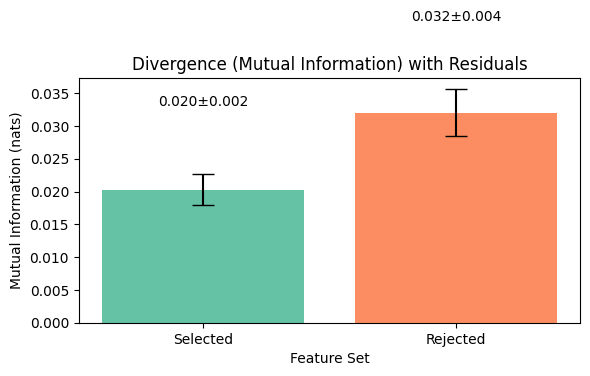

--- Mutual Information (KL-Divergence equivalent) ---
Average MI for SELECTED features: 0.02027 ± 0.00237
Average MI for REJECTED features: 0.03205 ± 0.00353
Time taken: 13.05 seconds


In [5]:
run(Config(
    baseline="xgboost",
    dataset_path="../data/ConcreteCompressiveStrength.csv",
    results_dir="../experiments_divergence/ConcreteCompressiveStrength",
    ignore_filter=True,
))

Optimal max_n_features_to_perturb: 1 (gap: 0.00342)
Optimal max_n_features_to_perturb: 1 (gap: 0.01334)
Optimal max_n_features_to_perturb: 1 (gap: 0.00845)
Optimal max_n_features_to_perturb: 10 (gap: 0.00935)
Optimal max_n_features_to_perturb: 8 (gap: 0.01019)
Optimal max_n_features_to_perturb: 10 (gap: 0.00629)
Optimal max_n_features_to_perturb: 5 (gap: -inf)
Optimal max_n_features_to_perturb: 10 (gap: 0.00795)
Optimal max_n_features_to_perturb: 1 (gap: 0.01265)
Optimal max_n_features_to_perturb: 2 (gap: 0.00455)
Optimal max_n_features_to_perturb: 10 (gap: -inf)
Optimal max_n_features_to_perturb: 7 (gap: 0.01142)
Optimal max_n_features_to_perturb: 10 (gap: 0.01172)
Optimal max_n_features_to_perturb: 10 (gap: 0.00459)
Optimal max_n_features_to_perturb: 9 (gap: 0.00618)


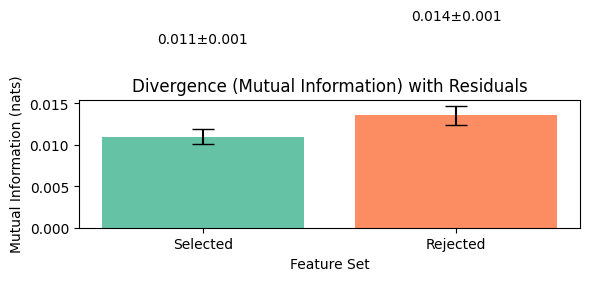

--- Mutual Information (KL-Divergence equivalent) ---
Average MI for SELECTED features: 0.01100 ± 0.00091
Average MI for REJECTED features: 0.01358 ± 0.00112
Time taken: 31.87 seconds


In [6]:
run(Config(
    baseline="xgboost",
    dataset_path="../data/WineQuality.csv",
    results_dir="../experiments_divergence/WineQuality",
    ignore_filter=True,
))

Optimal max_n_features_to_perturb: 9 (gap: 0.00536)
Optimal max_n_features_to_perturb: 1 (gap: 0.00815)
Optimal max_n_features_to_perturb: 10 (gap: 0.00279)
Optimal max_n_features_to_perturb: 2 (gap: 0.00294)
Optimal max_n_features_to_perturb: 19 (gap: -inf)
Optimal max_n_features_to_perturb: 14 (gap: 0.00583)
Optimal max_n_features_to_perturb: 11 (gap: 0.01216)
Optimal max_n_features_to_perturb: 2 (gap: 0.01424)
Optimal max_n_features_to_perturb: 10 (gap: 0.00407)
Optimal max_n_features_to_perturb: 18 (gap: 0.01103)
Optimal max_n_features_to_perturb: 10 (gap: 0.00192)
Optimal max_n_features_to_perturb: 10 (gap: 0.00345)
Optimal max_n_features_to_perturb: 17 (gap: 0.00841)
Optimal max_n_features_to_perturb: 9 (gap: 0.00140)
Optimal max_n_features_to_perturb: 3 (gap: 0.00873)


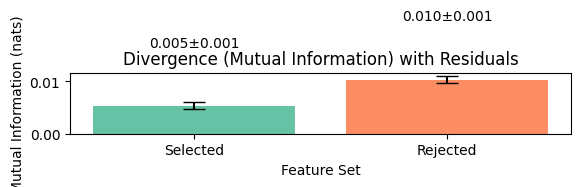

--- Mutual Information (KL-Divergence equivalent) ---
Average MI for SELECTED features: 0.00535 ± 0.00062
Average MI for REJECTED features: 0.01027 ± 0.00074
Time taken: 77.30 seconds


In [7]:
run(Config(
    baseline="xgboost",
    dataset_path="../data/ParkinsonsTelemonitoring.csv",
    results_dir="../experiments_divergence/ParkinsonsTelemonitoring",
    ignore_filter=True,
))

Optimal max_n_features_to_perturb: 9 (gap: 0.00556)
Optimal max_n_features_to_perturb: 6 (gap: -inf)
Optimal max_n_features_to_perturb: 9 (gap: 0.00873)
Optimal max_n_features_to_perturb: 4 (gap: 0.00241)
Optimal max_n_features_to_perturb: 6 (gap: 0.00639)
Optimal max_n_features_to_perturb: 7 (gap: -inf)
Optimal max_n_features_to_perturb: 10 (gap: 0.00378)
Optimal max_n_features_to_perturb: 11 (gap: 0.00639)
Optimal max_n_features_to_perturb: 4 (gap: 0.00080)
Optimal max_n_features_to_perturb: 9 (gap: -inf)
Optimal max_n_features_to_perturb: 7 (gap: 0.00263)
Optimal max_n_features_to_perturb: 8 (gap: 0.00002)
Optimal max_n_features_to_perturb: 11 (gap: -inf)
Optimal max_n_features_to_perturb: 7 (gap: 0.00726)
Optimal max_n_features_to_perturb: 8 (gap: -inf)


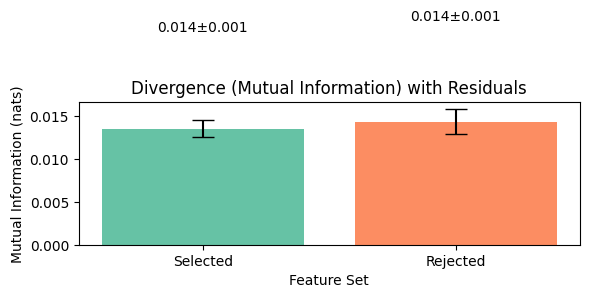

--- Mutual Information (KL-Divergence equivalent) ---
Average MI for SELECTED features: 0.01357 ± 0.00098
Average MI for REJECTED features: 0.01440 ± 0.00145
Time taken: 48.86 seconds


In [8]:
run(Config(
    baseline="xgboost",
    dataset_path="../data/227_cpu_small.csv",
    results_dir="../experiments_divergence/227_cpu_small",
    ignore_filter=True,
))

Optimal max_n_features_to_perturb: 5 (gap: -inf)
Optimal max_n_features_to_perturb: 1 (gap: 0.00749)
Optimal max_n_features_to_perturb: 12 (gap: -inf)
Optimal max_n_features_to_perturb: 11 (gap: -inf)
Optimal max_n_features_to_perturb: 2 (gap: 0.01225)
Optimal max_n_features_to_perturb: 5 (gap: -inf)
Optimal max_n_features_to_perturb: 12 (gap: -inf)
Optimal max_n_features_to_perturb: 1 (gap: 0.00671)
Optimal max_n_features_to_perturb: 7 (gap: 0.00517)
Optimal max_n_features_to_perturb: 4 (gap: 0.00395)
Optimal max_n_features_to_perturb: 13 (gap: 0.02091)
Optimal max_n_features_to_perturb: 13 (gap: -inf)
Optimal max_n_features_to_perturb: 8 (gap: 0.00480)
Optimal max_n_features_to_perturb: 11 (gap: 0.00825)
Optimal max_n_features_to_perturb: 1 (gap: 0.00873)


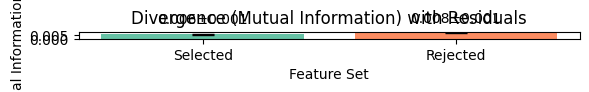

--- Mutual Information (KL-Divergence equivalent) ---
Average MI for SELECTED features: 0.00649 ± 0.00073
Average MI for REJECTED features: 0.00840 ± 0.00075
Time taken: 53.42 seconds


In [9]:
run(Config(
    baseline="xgboost",
    dataset_path="../data/503_wind.csv",
    results_dir="../experiments_divergence/503_wind",
    ignore_filter=True,
))

Optimal max_n_features_to_perturb: 6 (gap: 0.00614)
Optimal max_n_features_to_perturb: 7 (gap: 0.00414)
Optimal max_n_features_to_perturb: 7 (gap: 0.01529)
Optimal max_n_features_to_perturb: 8 (gap: 0.02131)
Optimal max_n_features_to_perturb: 8 (gap: 0.01714)
Optimal max_n_features_to_perturb: 7 (gap: 0.01649)
Optimal max_n_features_to_perturb: 1 (gap: 0.01736)
Optimal max_n_features_to_perturb: 4 (gap: 0.00204)
Optimal max_n_features_to_perturb: 7 (gap: 0.01068)
Optimal max_n_features_to_perturb: 6 (gap: 0.01646)
Optimal max_n_features_to_perturb: 1 (gap: 0.00556)
Optimal max_n_features_to_perturb: 3 (gap: 0.01761)
Optimal max_n_features_to_perturb: 3 (gap: 0.01171)
Optimal max_n_features_to_perturb: 2 (gap: 0.01742)
Optimal max_n_features_to_perturb: 7 (gap: 0.01624)


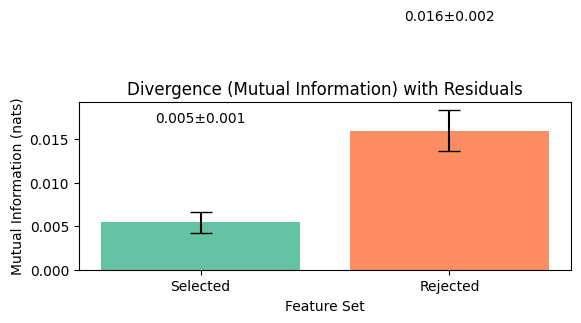

--- Mutual Information (KL-Divergence equivalent) ---
Average MI for SELECTED features: 0.00545 ± 0.00118
Average MI for REJECTED features: 0.01600 ± 0.00232
Time taken: 9.57 seconds


In [10]:
run(Config(
    baseline="xgboost",
    dataset_path="../data/EnergyEfficiency.csv",
    results_dir="../experiments_divergence/EnergyEfficiency",
    ignore_filter=True,
))

Optimal max_n_features_to_perturb: 6 (gap: 0.01307)
Optimal max_n_features_to_perturb: 9 (gap: 0.02112)
Optimal max_n_features_to_perturb: 4 (gap: 0.00812)
Optimal max_n_features_to_perturb: 3 (gap: 0.00366)
Optimal max_n_features_to_perturb: 2 (gap: 0.00933)
Optimal max_n_features_to_perturb: 9 (gap: 0.01095)
Optimal max_n_features_to_perturb: 7 (gap: 0.01103)
Optimal max_n_features_to_perturb: 9 (gap: 0.00126)
Optimal max_n_features_to_perturb: 6 (gap: 0.02007)
Optimal max_n_features_to_perturb: 1 (gap: 0.01643)
Optimal max_n_features_to_perturb: 5 (gap: 0.00542)
Optimal max_n_features_to_perturb: 8 (gap: 0.01164)
Optimal max_n_features_to_perturb: 9 (gap: 0.02141)
Optimal max_n_features_to_perturb: 7 (gap: 0.01343)
Optimal max_n_features_to_perturb: 7 (gap: 0.02226)


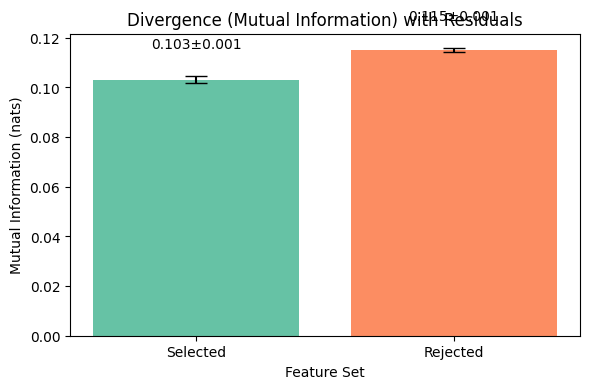

--- Mutual Information (KL-Divergence equivalent) ---
Average MI for SELECTED features: 0.10306 ± 0.00133
Average MI for REJECTED features: 0.11490 ± 0.00087
Time taken: 215.82 seconds


In [11]:
run(Config(
    baseline="xgboost",
    dataset_path="../data/294_satellite_image.csv",
    results_dir="../experiments_divergence/294_satellite_image",
    ignore_filter=True,
))

Optimal max_n_features_to_perturb: 9 (gap: 0.01502)
Optimal max_n_features_to_perturb: 2 (gap: 0.00312)
Optimal max_n_features_to_perturb: 1 (gap: -inf)
Optimal max_n_features_to_perturb: 9 (gap: 0.01493)
Optimal max_n_features_to_perturb: 3 (gap: -inf)
Optimal max_n_features_to_perturb: 9 (gap: 0.01503)
Optimal max_n_features_to_perturb: 7 (gap: 0.03135)
Optimal max_n_features_to_perturb: 7 (gap: 0.01545)
Optimal max_n_features_to_perturb: 9 (gap: -inf)
Optimal max_n_features_to_perturb: 9 (gap: 0.00796)
Optimal max_n_features_to_perturb: 4 (gap: 0.01506)
Optimal max_n_features_to_perturb: 7 (gap: 0.00928)
Optimal max_n_features_to_perturb: 4 (gap: 0.01718)
Optimal max_n_features_to_perturb: 9 (gap: 0.02184)
Optimal max_n_features_to_perturb: 1 (gap: 0.00944)


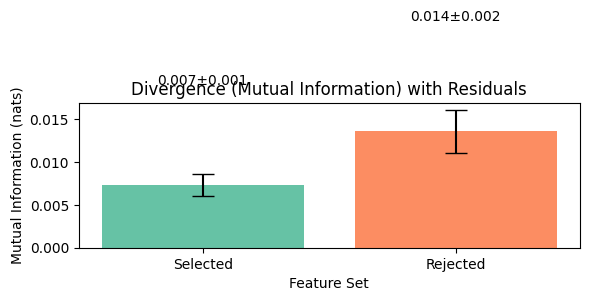

--- Mutual Information (KL-Divergence equivalent) ---
Average MI for SELECTED features: 0.00735 ± 0.00128
Average MI for REJECTED features: 0.01359 ± 0.00250
Time taken: 10.87 seconds


In [12]:
run(Config(
    baseline="xgboost",
    dataset_path="../data/623_fri_c4_1000_10.csv",
    results_dir="../experiments_divergence/623_fri_c4_1000_10",
    ignore_filter=True,
))

In [13]:
DF.to_csv("../experiments_divergence/comparison.csv", index=False)